In [27]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


2. Analisi del Dataset Titanic

2.1 Quante righe e colonne ha il dataset?

In [28]:
print("Numero righe: " + str(df.shape[0]))
print("Numero colonne: " + str(df.shape[1]))

Numero righe: 891
Numero colonne: 12


2.2 Controlla quanti valori mancanti ci sono per colonna

In [29]:
print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


2.3 Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente

In [30]:

df["Embarked"].fillna(df["Embarked"].mode()[0])

print(df["Embarked"])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str


2.4 Controlla se ci sono righe duplicate

In [31]:
if df.duplicated().any():
    
    print("Ci sono queste righe duplicate:")
    print(df[df.duplicated()])
    
else:
    print("Non ci sono righe duplicate")

Non ci sono righe duplicate


2.5 Calcola l'età media dei passeggeri per ogni classe (Pclass), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio

In [32]:
mean_age = df.groupby("Pclass")["Age"].mean()
print(mean_age)

df["Age"] = df["Age"].fillna(df.groupby("Pclass")["Age"].transform("mean"))

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


2.6 Visualizza la distribuzione dell'età per classe

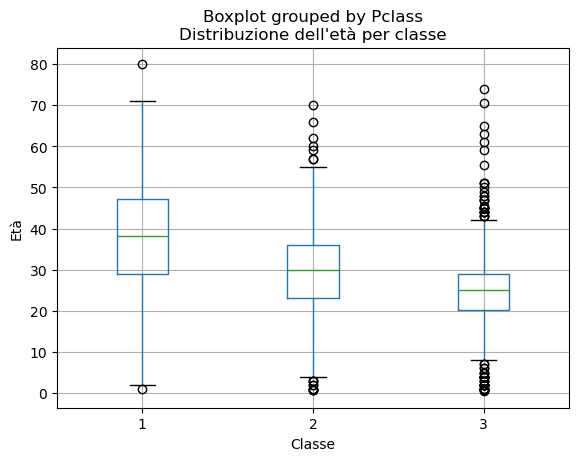

In [33]:
import matplotlib.pyplot as plt

df.boxplot(column = "Age", by = "Pclass")
plt.ylabel("Età")
plt.xlabel("Classe")
plt.title("Distribuzione dell'età per classe")

plt.show()


2.7 Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

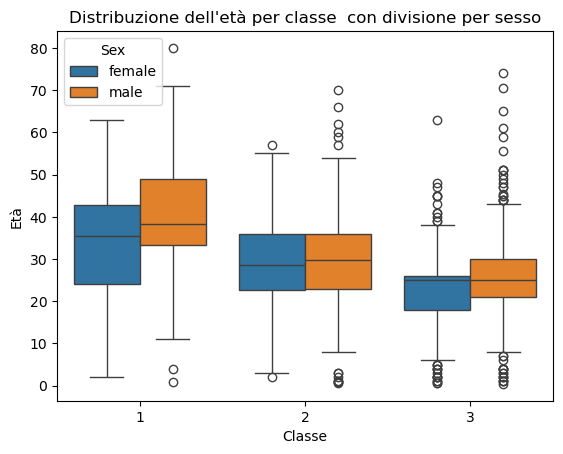

In [34]:
import seaborn as sns

sns.boxplot(x="Pclass", y="Age", hue="Sex", data=df)
plt.ylabel("Età")
plt.xlabel("Classe")
plt.title("Distribuzione dell'età per classe  con divisione per sesso")

plt.show()